## **Decision Trees: Classification**

### **Topic Roadmap**

**1. Dataset and train-test split**

**2. Fit a classification tree**

**3. Evaluate predictions**

**4. Visualize the learned tree and decision regions**

**5. Key revision notes**

## **1. Dataset and Train-Test Split**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
ads = pd.read_csv("docs/Lecture-069-Social_Network_Ads.csv")
ads = ads.rename(columns={"User ID": "user_id", "Gender": "gender", "Age": "age", "EstimatedSalary": "estimated_salary", "Purchased": "purchased"})
ads.head()

,user_id,gender,age,estimated_salary,purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
X = ads[["age", "estimated_salary"]]
y = ads["purchased"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

## **2. Fit a Decision Tree Classifier**

A decision tree recursively selects feature thresholds that reduce impurity. Trees do not require feature scaling, and `max_depth` controls model complexity.

In [4]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=4, criterion="gini", random_state=RANDOM_STATE)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [5]:
y_pred = tree_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=["Not purchased", "Purchased"]))

Accuracy: 0.863
               precision    recall  f1-score   support

Not purchased       0.90      0.88      0.89        51
    Purchased       0.80      0.83      0.81        29

     accuracy                           0.86        80
    macro avg       0.85      0.85      0.85        80
 weighted avg       0.86      0.86      0.86        80



## **3. Visualize the Tree**

The visualization shows the split feature, threshold, impurity, sample count, and predicted class at each node.

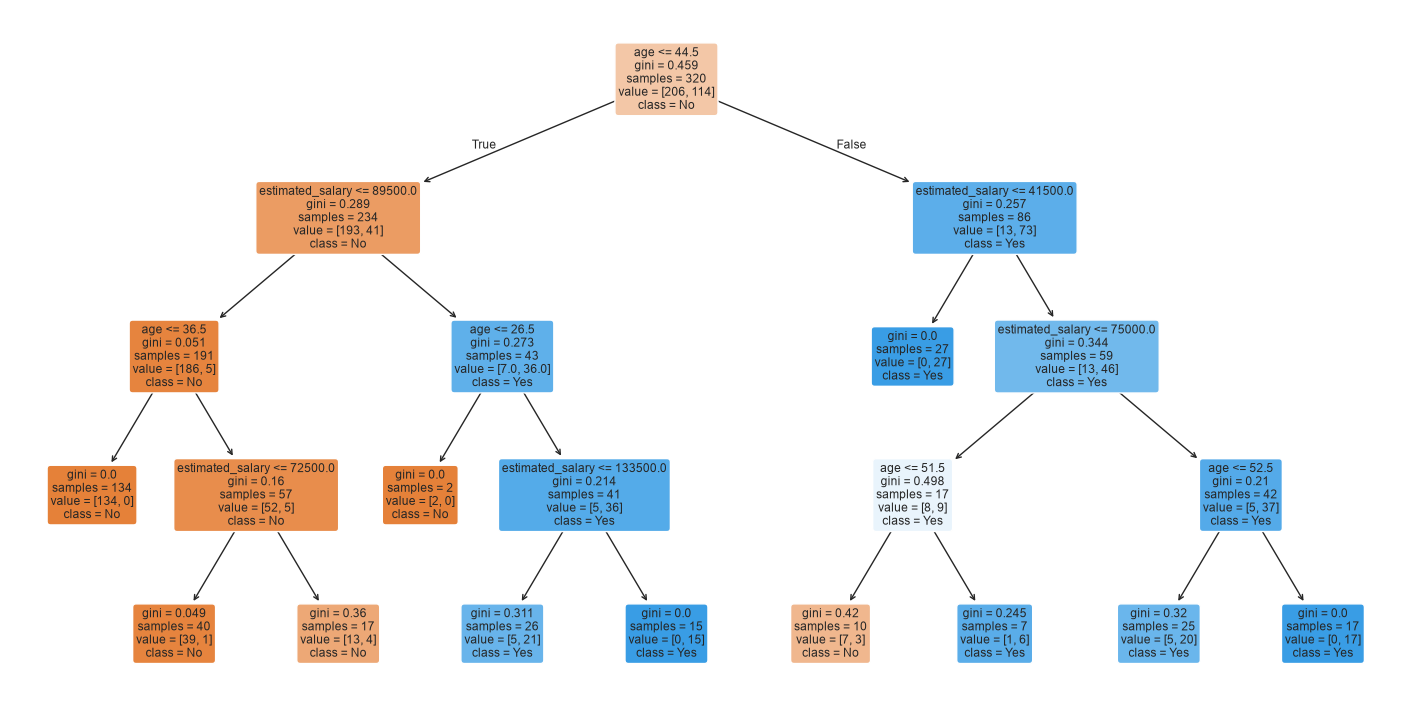

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 9))
plot_tree(tree_clf, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.show()

## **4. Decision Regions**

Decision trees create axis-aligned regions. The plot makes the piecewise nature of the classifier visible.

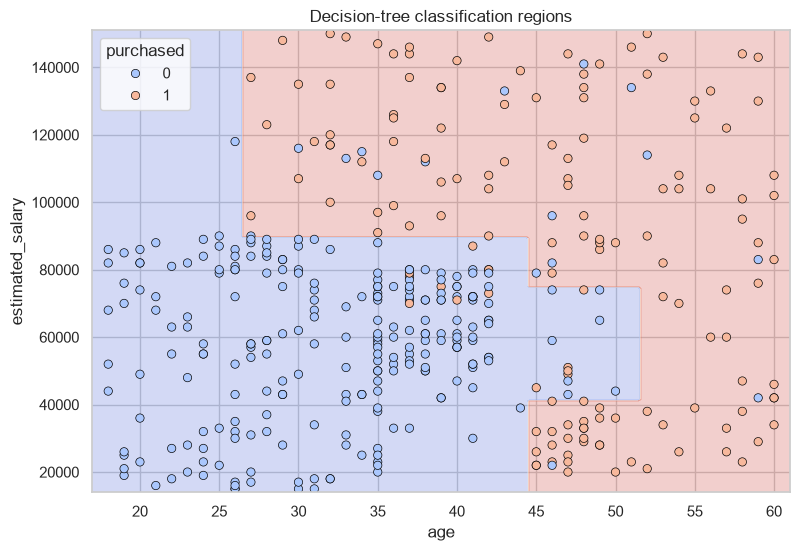

In [7]:
x_min, x_max = X["age"].min() - 1, X["age"].max() + 1
y_min, y_max = X["estimated_salary"].min() - 1000, X["estimated_salary"].max() + 1000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = pd.DataFrame({"age": xx.ravel(), "estimated_salary": yy.ravel()})
zz = tree_clf.predict(grid).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
sns.scatterplot(data=ads, x="age", y="estimated_salary", hue="purchased", palette="coolwarm", edgecolor="black")
plt.title("Decision-tree classification regions")
plt.show()

### **Key Revision Notes**

- A decision tree learns a sequence of if-then threshold rules.
- `max_depth`, `min_samples_leaf`, and pruning parameters control overfitting.
- Feature scaling is not required for tree-based models.
- The tree can model non-linear boundaries, but unrestricted depth often memorizes training data.